<a href="https://colab.research.google.com/github/Pooya-Moayed/Lattice-Bultzmann/blob/Pooya-Moayed-patch-1/Lattice_Bultzman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning (Lattice Bultzmann)**

## Lattice Bultzmann work space learning and applying on a simple tank and projection on a mixing tank



In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("comacque/computational-fluid-dynamics-mixing-tank")

# print("Path to dataset files:", path)

In [ ]:
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import os

In [ ]:
plot_every = 50
os.makedirs("frames", exist_ok=True)
dtype = np.float64

In [ ]:
def distance(x1, y1, x2, y2):
  return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [ ]:
# # def main():
#   Nx = 400
#   Ny = 100
#   tao = 0.53
#   Nt = 3000

#   # lattice speeds and weights
#   NL = 9
#   cxs = np.array (
#       [  0,   0,   0,   1,    1,    1,  -1,   -1,   -1]
#   )
#   cys = np.array (
#       [  0,   1,  -1,   0,    1,   -1,   0,    1,   -1]
#   )
#   weights = np.array (
#       [4/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/9, 1/36, 1/36] # sum to one
#   )

#   # initial conditions
#   F = np.ones((Ny,Nx, NL)) + 0.01 * np.random.randn(Ny,Nx, NL)
#   F[:, :, 3] = 2

#   # Defining cylinder
#   cylinder = np.full ((Ny, Nx), False)
#   for y in range (0, Ny):
#     for x in range (0, Nx):
#       if distance(Nx//4, Ny//2, x, y)<13:
#         cylinder[y] [x] = True
#   # main loop
#   for it in range(Nt):
#     print(it)

#     for i, cx, cy in zip(range(NL), cxs, cys):
#       F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
#       F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)


#   # Reflective boundaries
#     bndryF = F[cylinder, :]
#     bndryF = bndryF[:, [0, 2, 1, 6, 8, 7, 3, 5, 4]]

#   # Fluid variables
#     rho = np.sum (F, 2)
#     ux = np.sum (F * cxs, 2) / rho
#     uy = np.sum (F * cys, 2) / rho

#     F[cylinder, :] = bndryF
#     ux[cylinder, :] = 0
#     uy[cylinder, :] = 0

#   # Collision
#     Feq = np.zeros(F.shape)
#     for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
#       Feq[:, :, i] = rho * w * ( 1 + 3 * (cx*ux + cy*uy) + 9/2 * (cx * ux)**2 - 3/2 * (ux**2 + uy**2))

#     F += -(1.0 / tao) * (F - Feq)

#     #ploting

#     if(it%plot_every == 0):
#       pyplot.imshow(np.sqrt(ux**2 + uy**2))
#       pyplot.pause(.01)
#       pyplot.cla()

In [ ]:
# def main():
Nx = 400
Ny = 100
tao = 0.8
Nt = 3000

  # lattice speeds and weights
NL = 9
cxs = np.array (
    [  0,   0,   1,   1,    1,    0,  -1,   -1,   -1]
)
cys = np.array (
    [  0,   1,   1,   0,    1,   -1,  -1,    0,    1]
)
weights = np.array (
    [4/9, 1/9,1/36, 1/9, 1/36,  1/9,1/36,  1/9, 1/36] # sum to one
)

  # initial conditions
F = np.ones((Ny,Nx, NL)) + 0.01 * np.random.randn(Ny,Nx, NL)
F[:, :, 3] = 2

  # Defining cylinder
cylinder = np.full ((Ny, Nx), False)
for y in range (0, Ny):
  for x in range (0, Nx):
    if distance(Nx//4, Ny//2, x, y)<13:
      cylinder[y] [x] = True
  # main loop
for it in range(Nt):
  # print(it)

  for i, cx, cy in zip(range(NL), cxs, cys):
    F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
    F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)


  # Reflective boundaries
  bndryF = F[cylinder, :]
  bndryF = bndryF[:, [0,5,6,7,8,1,2,3,4]]

  # Fluid variables
  rho = np.sum(F, axis=2)
  mask = rho < 1e-12
  rho[mask] = 1.0  # just temporarily to avoid zero division
  ux = np.sum(F * cxs, axis=2) / rho
  uy = np.sum(F * cys, axis=2) / rho
  ux[mask] = 0.0
  uy[mask] = 0.0
  # rho = np.sum(F, axis=2)

  # ux = np.sum(F * cxs, axis=2) / rho
  # uy = np.sum(F * cys, axis=2) / rho


  F[cylinder, :] = bndryF
  ux[cylinder] = 0
  uy[cylinder] = 0


  # Collision
  Feq = np.zeros(F.shape)
  for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
    Feq[:, :, i] = rho * w * ( 1 + 3 * (cx*ux + cy*uy) + 9/2 * (cx * ux)**2 - 3/2 * (ux**2 + uy**2))

  F += -(1.0 / tao) * (F - Feq)

    #ploting

  if(it % plot_every == 0):
    vel = np.sqrt(ux**2 + uy**2)
    vel_norm = (vel - vel.min()) / (vel.max() - vel.min() + 1e-8)  # Avoid divide-by-zero
    plt.imshow(vel_norm)
    plt.axis('off')
    plt.savefig(f"frames/frame_{it:04d}.png", bbox_inches='tight', pad_inches=0)
    plt.clf()

/tmp/ipython-input-7-713108919.py:66: RuntimeWarning: overflow encountered in multiply
  F += -(1.0 / tao) * (F - Feq)
/tmp/ipython-input-7-713108919.py:46: RuntimeWarning: invalid value encountered in multiply
  ux = np.sum(F * cxs, axis=2) / rho
/tmp/ipython-input-7-713108919.py:47: RuntimeWarning: invalid value encountered in multiply
  uy = np.sum(F * cys, axis=2) / rho
/tmp/ipython-input-7-713108919.py:64: RuntimeWarning: overflow encountered in multiply
  Feq[:, :, i] = rho * w * ( 1 + 3 * (cx*ux + cy*uy) + 9/2 * (cx * ux)**2 - 3/2 * (ux**2 + uy**2))
/tmp/ipython-input-7-713108919.py:66: RuntimeWarning: invalid value encountered in add
  F += -(1.0 / tao) * (F - Feq)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-7-713108919.py:46: RuntimeWarning: invalid value encountered in divide
  ux = np.sum(F * cxs, axis=2) / rho
/tmp/ipython-i

<Figure size 640x480 with 0 Axes>

In [ ]:
import imageio.v2 as imageio
import glob

images = []
for filename in sorted(glob.glob("frames/frame_*.png")):
    images.append(imageio.imread(filename))

imageio.mimsave('simulation.gif', images, duration=0.1)

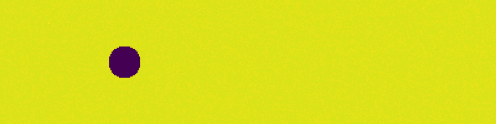

In [ ]:
from IPython.display import Image
Image(filename="simulation.gif")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Nx, Ny = 400, 100
tau = 0.6
Nt = 10000
u0 = 0.1
plot_every = 200

# Lattice parameters
NL = 9
cxs = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1])
cys = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1])
weights = np.array([4/9] + [1/9]*4 + [1/36]*4)

# Initialize distribution function
F = np.ones((Ny, Nx, NL)) + 0.01 * np.random.randn(Ny, Nx, NL)
rho = np.sum(F, axis=2)
ux = np.zeros((Ny, Nx))
uy = np.zeros((Ny, Nx))

# Cylinder mask
cylinder = np.fromfunction(
    lambda y, x: (x - Nx//4)**2 + (y - Ny//2)**2 < 13**2,
    (Ny, Nx)
)

# Main loop
for it in range(Nt):
    # Collision step
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs[None, None, :], axis=2) / rho
    uy = np.sum(F * cys[None, None, :], axis=2) / rho

    ux[cylinder] = 0
    uy[cylinder] = 0
    rho[cylinder] = np.sum(F[cylinder], axis=1)

    Feq = np.zeros_like(F)
    for i in range(NL):
        cu = 3 * (cxs[i]*ux + cys[i]*uy)
        Feq[:, :, i] = rho * weights[i] * (
            1 + cu + 0.5*cu**2 - 1.5*(ux**2 + uy**2)
        )

    F += -(1 / tau) * (F - Feq)

    # Streaming step
    for i in range(NL):
        F[:, :, i] = np.roll(F[:, :, i], cxs[i], axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cys[i], axis=0)

    # Bounce-back on cylinder
    bndryF = F[cylinder, :]
    F[cylinder, :] = bndryF[:, [0, 3, 4, 1, 2, 7, 8, 5, 6]]

    # Inlet condition (left wall)
    ux[:, 0] = u0
    uy[:, 0] = 0
    rho[:, 0] = 1.0 / (1 - ux[:, 0]) * (
        F[:, 0, 0] + F[:, 0, 2] + F[:, 0, 4] + 2*(F[:, 0, 3] + F[:, 0, 6] + F[:, 0, 7])
    )
    for i in range(NL):
        cu = 3 * (cxs[i]*ux[:, 0] + cys[i]*uy[:, 0])
        F[:, 0, i] = rho[:, 0] * weights[i] * (1 + cu + 0.5*cu**2 - 1.5*u0**2)

    # Outlet condition (copy from x = Nx-2)
    F[:, -1, :] = F[:, -2, :]
    # F[:, -1, :] = 2 * F[:, -2, :] - F[:, -3, :]
    # # Extrapolate outlet (with clipping to avoid crashing)
    # F[:, -1, :] = np.clip(2 * F[:, -2, :] - F[:, -3, :], 1e-5, 1e5)

    # # Light damping near outlet to absorb reflections
    # F[:, -3:, :] *= 0.995


    # Visualization
    if it % plot_every == 0:
        speed = np.sqrt(ux**2 + uy**2)
        plt.imshow(speed, cmap='plasma', origin='lower', vmax=0.2)
        plt.axis('off')
        plt.savefig(f"frames/frame1_{it:04d}.png", bbox_inches='tight', pad_inches=0)
        plt.clf()


<Figure size 640x480 with 0 Axes>

In [ ]:
import imageio.v2 as imageio
import glob

images = []
for filename in sorted(glob.glob("frames/frame1_*.png")):
    images.append(imageio.imread(filename))

imageio.mimsave('simulation1.gif', images, duration=0.1)

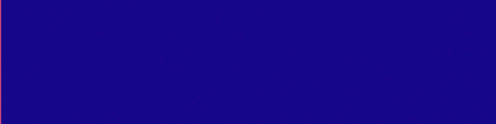

In [ ]:
from IPython.display import Image
Image(filename="simulation1.gif")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Nx, Ny = 400, 100
tau = 0.6
Nt = 10000
u0 = 0.1
plot_every = 50

# Lattice parameters
NL = 9
cxs = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1])
cys = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1])
weights = np.array([4/9] + [1/9]*4 + [1/36]*4)

# Initialize distribution function
F = np.ones((Ny, Nx, NL)) + 0.01 * np.random.randn(Ny, Nx, NL)
rho = np.sum(F, axis=2)
ux = np.zeros((Ny, Nx))
uy = np.zeros((Ny, Nx))

# Cylinder mask
cylinder = np.fromfunction(
    lambda y, x: (x - Nx//4)**2 + (y - Ny//2)**2 < 13**2,
    (Ny, Nx)
)

# Main loop
for it in range(Nt):
    # Collision step
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs[None, None, :], axis=2) / rho
    uy = np.sum(F * cys[None, None, :], axis=2) / rho

    ux[cylinder] = 0
    uy[cylinder] = 0
    rho[cylinder] = np.sum(F[cylinder], axis=1)

    Feq = np.zeros_like(F)
    for i in range(NL):
        cu = 3 * (cxs[i]*ux + cys[i]*uy)
        Feq[:, :, i] = rho * weights[i] * (
            1 + cu + 0.5*cu**2 - 1.5*(ux**2 + uy**2)
        )
    F[:, -5:, :] = 0.9 * F[:, -5:, :] + 0.1 * Feq[:, -5:, :]
    F += -(1 / tau) * (F - Feq)

    # Streaming step
    for i in range(NL):
        F[:, :, i] = np.roll(F[:, :, i], cxs[i], axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cys[i], axis=0)

    # Bounce-back on cylinder
    bndryF = F[cylinder, :]
    F[cylinder, :] = bndryF[:, [0, 3, 4, 1, 2, 7, 8, 5, 6]]

    # Inlet condition (left wall)
    ux[:, 0] = u0
    uy[:, 0] = 0
    rho[:, 0] = 1.0 / (1 - ux[:, 0]) * (
        F[:, 0, 0] + F[:, 0, 2] + F[:, 0, 4] + 2*(F[:, 0, 3] + F[:, 0, 6] + F[:, 0, 7])
    )
    for i in range(NL):
        cu = 3 * (cxs[i]*ux[:, 0] + cys[i]*uy[:, 0])
        F[:, 0, i] = rho[:, 0] * weights[i] * (1 + cu + 0.5*cu**2 - 1.5*u0**2)

    # Outlet condition (copy from x = Nx-2)
    # F[:, -1, :] = F[:, -2, :]
    # F[:, -1, :] = 2 * F[:, -2, :] - F[:, -3, :]
    # # Extrapolate outlet (with clipping to avoid crashing)
    # F[:, -1, :] = np.clip(2 * F[:, -2, :] - F[:, -3, :], 1e-5, 1e5)

    # # Light damping near outlet to absorb reflections
    # F[:, -3:, :] *= 0.995
    F[:, -5:, :] *= 0.995


    # Visualization
    if it % plot_every == 0:
        speed = np.sqrt(ux**2 + uy**2)
        plt.imshow(speed, cmap='plasma', origin='lower', vmax=0.2)
        plt.axis('off')
        plt.savefig(f"frames/frame2_{it:04d}.png", bbox_inches='tight', pad_inches=0)
        plt.clf()


<Figure size 640x480 with 0 Axes>

In [ ]:
import imageio.v2 as imageio
import glob

images = []
for filename in sorted(glob.glob("frames/frame2_*.png")):
    images.append(imageio.imread(filename))

imageio.mimsave('simulation2.gif', images, duration=0.1)

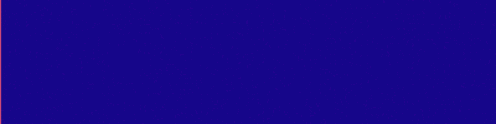

In [ ]:
from IPython.display import Image
Image(filename="simulation2.gif")